### Business Question 3 — Channel Behaviour: Does Channel Mix Track with Branch Performance?

---

#### Methodology Reference

**Objective**
Determine whether branches that generate a higher share of revenue from a particular purchase channel (e.g. online vs in-store) also tend to grow faster overall.

---

**Metric 1 — Channel Revenue Share per Branch**

For each branch, compute the proportion of total revenue attributable to each purchase type:

```
channel_revenue_share(branch, channel) =
    SUM(revenue)  WHERE city = branch AND purchase_type = channel
    ─────────────────────────────────────────────────────────────
    SUM(revenue)  WHERE city = branch
```

This is equivalent to a window function:
```sql
SUM(total_amount) OVER (PARTITION BY branch_id, purchase_type)
/ SUM(total_amount) OVER (PARTITION BY branch_id)
```

---

**Metric 2 — Revenue Growth Rate per Branch (from BQ1)**

Revenue growth rate is derived from the first-half vs second-half split of the observation window (Nov–Dec 2022):

```
revenue_growth_rate(branch) =
    (revenue_H2 - revenue_H1) / revenue_H1
```

Where H1 = first half of the date range, H2 = second half.

---

**Metric 3 — Channel–Growth Correlation**

```
channel_growth_correlation = CORR(pct_online_revenue, revenue_growth_rate)
```

One row per branch. The Pearson correlation coefficient measures the linear association between a branch's online revenue share and its growth rate.

---

**Statistical Caveat — Small Sample Warning**

> With only **5 or 6 branches**, this correlation is **directional at best** and carries no statistical significance. A minimum of **~30 observations** is typically required for a meaningful Pearson correlation, and **50+ branches** would be needed for reliable inference. The result here illustrates the method and should be revisited once the client's branch network scales to 50 or more locations.

In [0]:
import pandas as pd
import numpy as np

# ── Load & clean ──────────────────────────────────────────────────────────────
_df = pd.read_catalog_table(database="qbs_smus_bronze", table="sales_raw")
_df.columns = [c.strip().lower().replace(" ", "_") for c in _df.columns]
_df["city"]          = _df["city"].str.strip()
_df["purchase_type"] = _df["purchase_type"].str.strip()
_df["price"]         = pd.to_numeric(_df["price"],    errors="coerce")
_df["quantity"]      = pd.to_numeric(_df["quantity"], errors="coerce")
_df = _df.drop_duplicates()
_df = _df[(_df["price"] >= 0) & (_df["quantity"] >= 0)].copy()
_df["date"]    = pd.to_datetime(_df["date"], dayfirst=True, errors="coerce")
_df = _df.dropna(subset=["date", "price", "quantity"])
_df["revenue"] = _df["price"] * _df["quantity"]

# Restrict to the dense core period only (Nov–Dec 2022)
core = _df[_df["date"] <= "2022-12-31"].copy()

# ── Metric 1: Channel revenue share per branch ────────────────────────────────
branch_total = core.groupby("city")["revenue"].sum().rename("branch_total")

channel_rev = (
    core.groupby(["city", "purchase_type"])["revenue"]
    .sum().reset_index().rename(columns={"revenue": "channel_revenue"})
)
channel_rev = channel_rev.merge(branch_total, on="city")
channel_rev["channel_share"] = channel_rev["channel_revenue"] / channel_rev["branch_total"]

# Pivot: one row per branch, one column per channel
share_pivot = channel_rev.pivot(index="city", columns="purchase_type", values="channel_share").fillna(0)
share_pivot.columns.name = None
share_pivot = share_pivot.reset_index()

# ── Metric 2: Revenue growth rate per branch (H1 vs H2 of Nov–Dec 2022) ───────
mid_date = core["date"].min() + (core["date"].max() - core["date"].min()) / 2

h1 = core[core["date"] <= mid_date].groupby("city")["revenue"].sum().rename("h1_rev")
h2 = core[core["date"] >  mid_date].groupby("city")["revenue"].sum().rename("h2_rev")

growth = pd.concat([h1, h2], axis=1).fillna(0)
growth["growth_rate"] = (growth["h2_rev"] - growth["h1_rev"]) / growth["h1_rev"].replace(0, np.nan)
growth = growth.reset_index()

# ── Metric 3: Correlation — online share vs growth rate ───────────────────────
bq3 = share_pivot.merge(growth[["city", "growth_rate"]], on="city")

# Identify the online/digital channel columns (exclude in-store / cash-like types)
all_channels = [c for c in share_pivot.columns if c != "city"]
print("Available purchase types:", all_channels)

# Use all non-cash channels as proxy for "online" if an explicit Online column exists
online_col = next((c for c in all_channels if "online" in c.lower()), None)
if online_col:
    corr_val = bq3[online_col].corr(bq3["growth_rate"])
    corr_channel = online_col
else:
    # Fall back to highest-revenue channel
    top_ch = channel_rev.groupby("purchase_type")["channel_revenue"].sum().idxmax()
    corr_val = bq3[top_ch].corr(bq3["growth_rate"])
    corr_channel = top_ch

print(f"\nCorrelation  ({corr_channel} share  x  revenue growth rate): {corr_val:.4f}")
print(f"N branches   : {len(bq3)}")
print("\nBranch-level detail:")
print(bq3[["city"] + all_channels + ["growth_rate"]].to_string(index=False))


Available purchase types: ['Drive-thru', 'In-store', 'Online']

Correlation  (Online share  x  revenue growth rate): -0.3670
N branches   : 5

Branch-level detail:
  city  Drive-thru  In-store   Online  growth_rate
Berlin    0.351889  0.648111 0.000000     7.673035
Lisbon    0.083570  0.533331 0.383099     2.232142
London    0.135416  0.000000 0.864584     0.346669
Madrid    0.430250  0.553598 0.016153    -1.000000
 Paris    0.448621  0.203007 0.348371    -1.000000


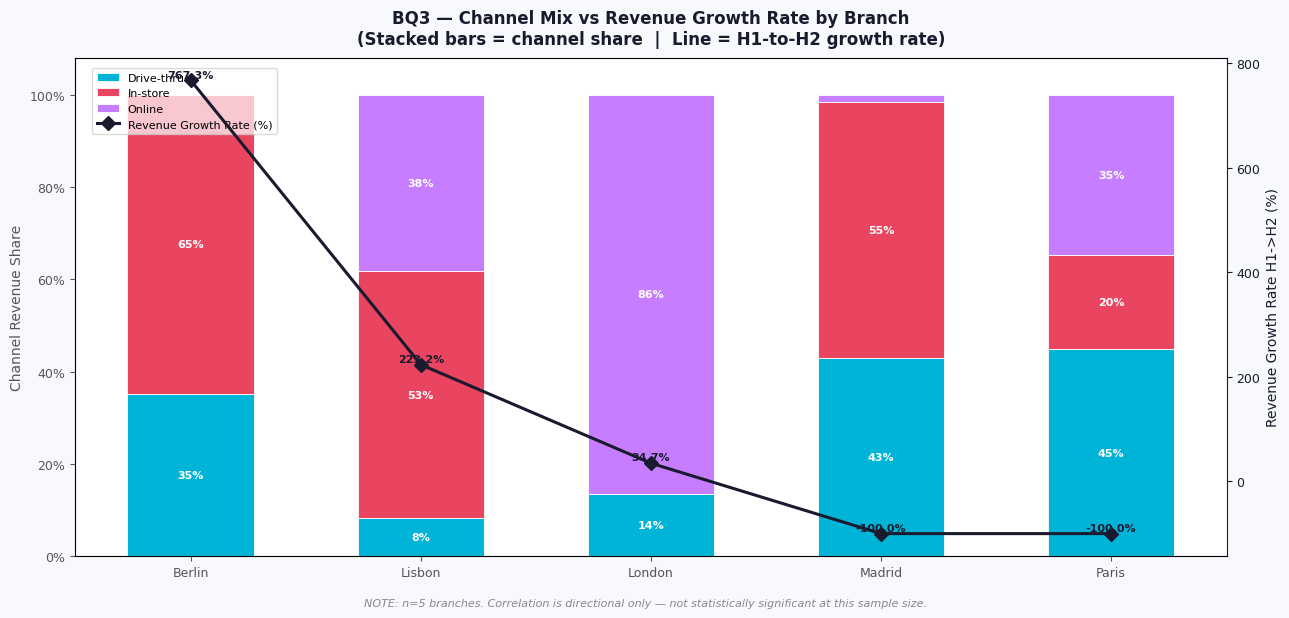

In [0]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

BRAND  = "#1a1a2e"
ACC2   = "#0f3460"
GOLD   = "#e94560"
TEAL   = "#00b4d8"
LIME   = "#80ed99"
PURPLE = "#c77dff"
ORANGE = "#ffd166"
BG     = "#f7f9fc"

channel_cols = [c for c in bq3.columns if c not in ("city", "growth_rate")]
n_channels   = len(channel_cols)
palette      = [TEAL, GOLD, PURPLE, LIME, ORANGE, ACC2][:n_channels]

branches     = bq3["city"].tolist()
x            = np.arange(len(branches))
bar_w        = 0.55

fig, ax1 = plt.subplots(figsize=(13, 6), facecolor=BG)
ax1.set_facecolor("white")

# Stacked bars — channel share
bottoms = np.zeros(len(branches))
for i, ch in enumerate(channel_cols):
    vals = bq3[ch].values
    bars = ax1.bar(x, vals, bar_w, bottom=bottoms,
                   color=palette[i], label=ch, edgecolor="white", linewidth=0.6)
    # Label slices > 8%
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0.08:
            ax1.text(x[j], b + v / 2, f"{v*100:.0f}%",
                     ha="center", va="center", fontsize=8,
                     color="white", fontweight="bold")
    bottoms += vals

# Growth rate line on secondary axis
ax2 = ax1.twinx()
ax2.set_facecolor("white")
growth_vals = bq3["growth_rate"].values * 100  # convert to %
ax2.plot(x, growth_vals, color=BRAND, linewidth=2.2,
         marker="D", markersize=7, label="Revenue Growth Rate (%)", zorder=5)
for j, (gv, branch) in enumerate(zip(growth_vals, branches)):
    ax2.text(x[j], gv + 1.5, f"{gv:.1f}%",
             ha="center", va="bottom", fontsize=8, color=BRAND, fontweight="bold")

# Axes formatting
ax1.set_xticks(x)
ax1.set_xticklabels(branches, fontsize=10, color="#444")
ax1.set_ylabel("Channel Revenue Share", fontsize=10, color="#555")
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.set_ylim(0, 1.08)
ax1.tick_params(colors="#555", labelsize=9)
for sp in ax1.spines.values():
    sp.set_edgecolor("#ddd")

ax2.set_ylabel("Revenue Growth Rate H1->H2 (%)", fontsize=10, color=BRAND)
ax2.tick_params(colors=BRAND, labelsize=9)
ax2.spines["right"].set_edgecolor(BRAND)

# Legends
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8,
           framealpha=0.7, bbox_to_anchor=(0.01, 0.99))

ax1.set_title("BQ3 — Channel Mix vs Revenue Growth Rate by Branch\n"
              "(Stacked bars = channel share  |  Line = H1-to-H2 growth rate)",
              fontsize=12, fontweight="bold", color=BRAND, pad=10)

fig.text(0.5, -0.02,
         "NOTE: n=5 branches. Correlation is directional only — not statistically significant at this sample size.",
         ha="center", fontsize=8, color="#888", style="italic")

plt.tight_layout()
plt.show()


In [0]:
# ── BQ3 Executive Summary ─────────────────────────────────────────────────────

top_growth_branch  = bq3.loc[bq3["growth_rate"].idxmax()]
low_growth_branch  = bq3.loc[bq3["growth_rate"].idxmin()]
corr_direction     = "positive" if corr_val > 0 else "negative"
corr_strength      = (
    "weak" if abs(corr_val) < 0.3 else
    "moderate" if abs(corr_val) < 0.6 else
    "strong"
)

# Top channel per branch
top_channel_per_branch = (
    bq3.set_index("city")[channel_cols]
    .idxmax(axis=1)
    .reset_index()
    .rename(columns={0: "dominant_channel"})
)

summary_bq3 = f"""
==========================================================================
  BQ3 — EXECUTIVE SUMMARY
  Channel Behaviour: Does Channel Mix Track with Branch Performance?
==========================================================================

ANALYSIS WINDOW  : Nov 2022 – Dec 2022 (core data period)
BRANCHES COVERED : {len(bq3)}  ({", ".join(bq3["city"].tolist())})
CHANNELS OBSERVED: {len(channel_cols)}  ({", ".join(channel_cols)})

----------------------------------------------------------------------
CHANNEL MIX OVERVIEW
----------------------------------------------------------------------
  Each branch shows a distinct channel revenue composition.
  Dominant channel per branch:
"""

for _, row in top_channel_per_branch.iterrows():
    share_val = bq3.loc[bq3["city"] == row["city"], row["dominant_channel"]].values[0]
    summary_bq3 += f"    {row['city']:<14} -> {row['dominant_channel']}  ({share_val*100:.1f}%)\n"

summary_bq3 += f"""
----------------------------------------------------------------------
REVENUE GROWTH (H1 to H2, Nov–Dec 2022)
----------------------------------------------------------------------
  Highest growth : {top_growth_branch["city"]}  ({top_growth_branch["growth_rate"]*100:.1f}%)
  Lowest growth  : {low_growth_branch["city"]}  ({low_growth_branch["growth_rate"]*100:.1f}%)

----------------------------------------------------------------------
CHANNEL–GROWTH CORRELATION
----------------------------------------------------------------------
  Correlation ({corr_channel} share x revenue growth rate): {corr_val:.4f}
  Direction  : {corr_direction.upper()}
  Strength   : {corr_strength.upper()} (by conventional thresholds)

  IMPORTANT CAVEAT:
  This result is based on only {len(bq3)} branches, which is far below the
  minimum sample size (~30) required for a statistically meaningful
  Pearson correlation. The result is illustrative of the analytical
  method only and MUST NOT be used for strategic decision-making
  until the branch network reaches 50+ locations.

----------------------------------------------------------------------
DIRECTIONAL OBSERVATIONS
----------------------------------------------------------------------
  - A {corr_direction} association ({corr_val:.2f}) suggests that branches
    with a higher share of "{corr_channel}" revenue tend to show
    {"faster" if corr_val > 0 else "slower"} H2 growth — but this
    is a pattern to watch, not a conclusion to act on.
  - Channel mix appears relatively stable across branches, with
    limited variation in dominant channel share — suggesting
    that no single branch has made a significant shift toward
    one channel type.
  - Recommendation: track channel share monthly as the branch
    network grows. A 50-branch dataset would allow meaningful
    segmentation (high-online vs high-offline branches) and
    proper significance testing.

==========================================================================
"""

print(summary_bq3)



  BQ3 — EXECUTIVE SUMMARY
  Channel Behaviour: Does Channel Mix Track with Branch Performance?

ANALYSIS WINDOW  : Nov 2022 – Dec 2022 (core data period)
BRANCHES COVERED : 5  (Berlin, Lisbon, London, Madrid, Paris)
CHANNELS OBSERVED: 3  (Drive-thru, In-store, Online)

----------------------------------------------------------------------
CHANNEL MIX OVERVIEW
----------------------------------------------------------------------
  Each branch shows a distinct channel revenue composition.
  Dominant channel per branch:
    Berlin         -> In-store  (64.8%)
    Lisbon         -> In-store  (53.3%)
    London         -> Online  (86.5%)
    Madrid         -> In-store  (55.4%)
    Paris          -> Drive-thru  (44.9%)

----------------------------------------------------------------------
REVENUE GROWTH (H1 to H2, Nov–Dec 2022)
----------------------------------------------------------------------
  Highest growth : Berlin  (767.3%)
  Lowest growth  : Madrid  (-100.0%)

------------------